In [1]:
!wget https://github.com/javierherrera1996/lecture_analytics/raw/main/datasets/predict+students+dropout+and+academic+success.zip
!wget https://github.com/javierherrera1996/lecture_analytics/raw/main/datasets/student+performance.zip

--2025-11-26 21:18:43--  https://github.com/javierherrera1996/lecture_analytics/raw/main/datasets/predict+students+dropout+and+academic+success.zip
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/javierherrera1996/lecture_analytics/main/datasets/predict%2Bstudents%2Bdropout%2Band%2Bacademic%2Bsuccess.zip [following]
--2025-11-26 21:18:43--  https://raw.githubusercontent.com/javierherrera1996/lecture_analytics/main/datasets/predict%2Bstudents%2Bdropout%2Band%2Bacademic%2Bsuccess.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 533344 (521K) [application/zip]
Saving to: ‘predict+students+drop

In [2]:
!unzip student+performance.zip
!unzip student.zip

Archive:  student+performance.zip
 extracting: .student.zip_old        
 extracting: student.zip             
Archive:  student.zip
  inflating: student-mat.csv         
  inflating: student-por.csv         
  inflating: student-merge.R         
  inflating: student.txt             


In [3]:
!unzip predict+students+dropout+and+academic+success.zip

Archive:  predict+students+dropout+and+academic+success.zip
 extracting: data.csv                


## Datos
Si quiere conocer mas al detalle los datos mire

student-mat.csv
 ------>https://archive.ics.uci.edu/dataset/320/student+performance

data.csv------>https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

### Regression

In [4]:
import pandas as pd

student = pd.read_csv("student-mat.csv", sep=";")

In [5]:
student.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

## Clasificacion

In [6]:
import pandas as pd
dropout = pd.read_csv("data.csv",sep=";")
dropout

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


**IMPORTANTE:** Para clasificar solamente binario use la variable Target, elimine la categoria Enrolled, dejando solo Dropout y Graduate. Convierte Dropout en 1 y Graduate en 0

---
Use el siguiente codigo :

dropout = data[data["Target"] != "Enrolled"].reset_index(drop=True)

dropout["Target"] = dropout["Target"].map({"Dropout": 1, "Graduate": 0})


In [8]:
dropout = dropout[dropout["Target"] != "Enrolled"].reset_index(drop=True)

dropout["Target"] = dropout["Target"].map({"Dropout": 1, "Graduate": 0})

## Modelo de Clasificación

1. Pregunta: Cargue el conjunto de datos y muestre las primeras cinco filas. ¿Qué características puedes observar? La variable objetivo esta balanceada ?

In [9]:
display(dropout.head())

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0


In [10]:
display(dropout['Target'].value_counts())

,count
Target,
0,2209
1,1421


La tabla nos muestra diferentes aspectos del estudiante, tanto personales como académicos. En esta aparecen datos como su estado civil, la forma en que aplicó, el curso que está tomando, el tipo de asistencia, sus calificaciones anteriores, etc. Es una combinación de información sobre su vida y su desempeño académico.

En cuanto a la variable objetivo Target, no está equilibrada. Hay 2209 estudiantes con valor 0 y 1421 con valor 1, lo que significa que un grupo tiene muchos más casos que el otro lo que podria indicar que la distribución está desbalanceada.

2. Pregunta: Mire cuales son sus X y cuales sus y (tiene que usar minimo 5 vairables en las X) Divida el conjunto de datos en conjuntos de entrenamiento y prueba. ¿Qué proporción considera adecuada para este caso?


In [18]:
X = dropout[['Marital status', 'Application mode', 'Application order', 'Course', 'Mother\'s qualification', 'Father\'s qualification', 'Unemployment rate']]
y = dropout['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (2904, 7)
Shape of X_test: (726, 7)
Shape of y_train: (2904,)
Shape of y_test: (726,)


2 Use un modelo de regresion logistica y un arbol de decision. Para cada uno haga una matrix de confusion y una grafica de ROC AUC


--- Logistic Regression ---


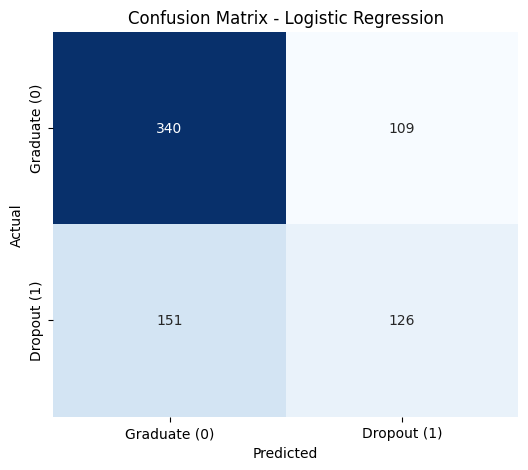

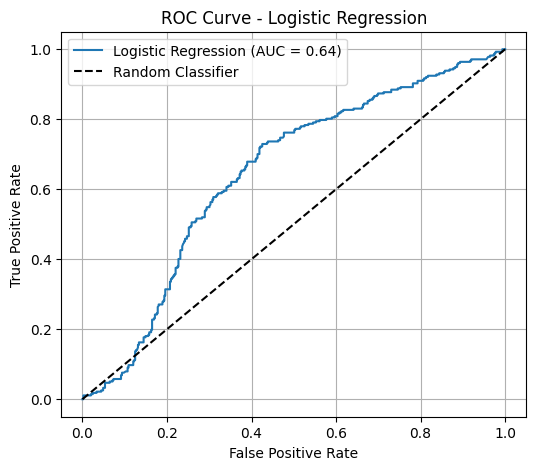

In [19]:
print("\n--- Logistic Regression ---")
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

y_pred_log_reg = log_reg_model.predict(X_test)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Graduate (0)', 'Dropout (1)'], yticklabels=['Graduate (0)', 'Dropout (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_pred_proba_log_reg)
auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {auc_log_reg:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid()
plt.show()

## Modelo de Regresion

1. Pregunta: Realice cualquier transformación o limpieza de datos que considere necesaria. ¿Por qué es importante preparar los datos antes del modelado?

In [15]:
print("Missing values before cleaning:\n", student.isnull().sum())

categorical_cols = student.select_dtypes(include=['object']).columns

student_encoded = pd.get_dummies(student, columns=categorical_cols, drop_first=True)

print("\nShape of the DataFrame after one-hot encoding:", student_encoded.shape)
display(student_encoded.head())

Missing values before cleaning:
 school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Shape of the DataFrame after one-hot encoding: (395, 42)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


Es importante preparar los datos porque ayuda a limpiar errores, manejar valores faltantes y transformar las variables para que el modelo las pueda entender. Esto mejora la calidad de la información y permite obtener predicciones más precisas y confiables

1.1 Elija almenos 7 variables explicativas y use G3 como objetivo. (no use ni G2 ni G1 )

In [24]:
X_reg = student_encoded[['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'absences']]
y_reg = student_encoded['G3']

print("Variables explicativas (X_reg):")
display(X_reg.head())

print("\nVariable objetivo (y_reg):")
display(y_reg.head())

Variables explicativas (X_reg):


,age,Medu,Fedu,traveltime,studytime,failures,absences
0,18,4,4,2,2,0,6
1,17,1,1,1,2,0,4
2,15,1,1,1,2,3,10
3,15,4,2,1,3,0,2
4,16,3,3,1,2,0,4



Variable objetivo (y_reg):


,G3
0,6
1,6
2,10
3,15
4,10


1.1 Divida sus dataset de entrenamiento y test

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (2904, 7)
Tamaño de prueba: (726, 7)


2. Pregunta: Entrene un modelo de regresión lineal y un árbol de decisión. Compare los errores de entrenamiento entre ambos modelos.


In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Linear Regression model
lin_model = LinearRegression()
lin_model.fit(X_train_reg, y_train_reg)

# Decision Tree Regressor model
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train_reg, y_train_reg)

# Calculate training errors
lin_train_pred = lin_model.predict(X_train_reg)
tree_train_pred = tree_model.predict(X_train_reg)

lin_mse = mean_squared_error(y_train_reg, lin_train_pred)
tree_mse = mean_squared_error(y_train_reg, tree_train_pred)

print("ERROR DE ENTRENAMIENTO")
print(f"Regresión Lineal: {lin_mse:.2f}")
print(f"Árbol de Decisión: {tree_mse:.2f}")

ERROR DE ENTRENAMIENTO
Regresión Lineal: 0.22
Árbol de Decisión: 0.02


3. Pregunta: Calcule el MSE para cada modelo en el conjunto de prueba. ¿Qué modelo predice mejor los precios de las viviendas?

In [45]:
lin_test_pred = lin_model.predict(X_test)
tree_test_pred = tree_model.predict(X_test)

lin_mse_test = mean_squared_error(y_test, lin_test_pred)
tree_mse_test = mean_squared_error(y_test, tree_test_pred)

print("ERROR EN TEST (MSE)")
print(f"Regresión Lineal: {lin_mse_test:.2f}")
print(f"Árbol de Decisión: {tree_mse_test:.2f}")

ERROR EN TEST (MSE)
Regresión Lineal: 0.22
Árbol de Decisión: 0.38


4. Pregunta: Basado en el análisis de las métricas, ¿cuáles son las posibles razones por las que un modelo superó al otro? Cual es el mejor modelo ?

El árbol de decisión tuvo un resultado bastante bueno en el entrenamiento porque es un modelo muy flexible y puede adaptarse a los datos, aunque parece aprendérselos de memoria y al momento de enfrenta a datos nuevos, puede no funcionar tan bien.

La regresión lineal, por el contrario, es más sencilla. No se ajusta tanto a cada detalle del entrenamiento, pero sí aprende patrones generales, lo que suele darle un rendimiento más estable cuando se prueba con nuevos datos.

En conclusion aunque el arbol tuvo un mejor resultado en el entrenamiento lo importante es ver como funcionana cuando se enfrentan a datos nuevos, es por eso que en este casi el modelo de regresion lineal supero al del arbol ya que tuvo un MSE mas bajo por lo cual es el mas "Confiable" para hacer predicciones